In [188]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [189]:
# Chargement des datasets
evaluation = pd.read_csv("Datasets/assessments.csv") 
notes_etudiants = pd.read_csv("Datasets/studentAssessment.csv")
profil_etudiants = pd.read_csv("Datasets/studentInfo.csv")
inscription = pd.read_csv("Datasets/studentRegistration.csv")
interactions_plateforme  = pd.read_csv("Datasets/studentVle.csv ") # Fichier qui enregistre chaque clic de chaque etudaint sur la plateforme
ressources_pedago = pd.read_csv("Datasets/vle.csv")  #Repertoire de toutes les ressources disponible sur la plateforme

<h3 style = "background : blue; width : 800px">
    01 - 
    Netoyage et Analyse du dataset evaluation
</h3>

In [190]:
evaluation.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0


In [191]:
evaluation.shape

(206, 6)

In [192]:
evaluation.columns

Index(['code_module', 'code_presentation', 'id_assessment', 'assessment_type',
       'date', 'weight'],
      dtype='str')

In [193]:
# Renommer les colonnes en français
evaluation = evaluation.rename(columns={
    'code_module': 'code_module',
    'code_presentation': 'code_presentation',
    'id_assessment': 'id_evaluation',
    'assessment_type': 'type_evaluation',
    'date': 'jours_limite_rendu',  # Nombre de jours depuis le début du cours pour rendre le devoir
    'weight': 'coefficient'         # Poids de l'évaluation sur 100
})
evaluation.columns

Index(['code_module', 'code_presentation', 'id_evaluation', 'type_evaluation',
       'jours_limite_rendu', 'coefficient'],
      dtype='str')

In [194]:
evaluation.info()

<class 'pandas.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code_module         206 non-null    str    
 1   code_presentation   206 non-null    str    
 2   id_evaluation       206 non-null    int64  
 3   type_evaluation     206 non-null    str    
 4   jours_limite_rendu  195 non-null    float64
 5   coefficient         206 non-null    float64
dtypes: float64(2), int64(1), str(3)
memory usage: 12.0 KB


In [195]:
val_manque = evaluation.isnull().mean()*100
val_manque.sort_values(ascending=False).round(2)

jours_limite_rendu    5.34
code_module           0.00
code_presentation     0.00
id_evaluation         0.00
type_evaluation       0.00
coefficient           0.00
dtype: float64

In [196]:
# Le dataset contient des valeurs manquantes dans la colonne "jours_limite_rendu" (date de rendu de l'évaluation) environ 5, 34% de valeur manquates. Il est important de traiter ces valeurs manquantes avant d'effectuer toute analyse.

In [197]:
evaluation["type_evaluation"].value_counts()

type_evaluation
TMA     106
CMA      76
Exam     24
Name: count, dtype: int64

In [198]:
# Remplacer les types d'évaluations par leurs noms en français
evaluation['type_evaluation'] = evaluation['type_evaluation'].replace({
    'TMA': 'Devoir écrit (Tuteur)',
    'CMA': 'Quiz en ligne (Ordinateur)',
    'Exam': 'Examen final'
})

In [199]:
evaluation[evaluation['jours_limite_rendu'].isna()]["type_evaluation"].value_counts()

type_evaluation
Examen final    11
Name: count, dtype: int64

J'ai tester de voir pour quelle type d'évaluation les valeurs manquantes sont présentes. 
Il s'avère que les valeurs manquantes sont présentes uniquement pour les évaluations de type "Examen final". 
Cela peut être dû au fait que la date limite de rendu pour les examens finaux n'est pas applicable,
  car ils ont lieu à une date fixe et ne sont pas soumis à un délai de rendu comme 
les devoirs ou les quiz.

- `Petit visualisation de la répartition des types d'évaluations`

Text(0.5, 1.0, "Répartition des types d'évaluations")

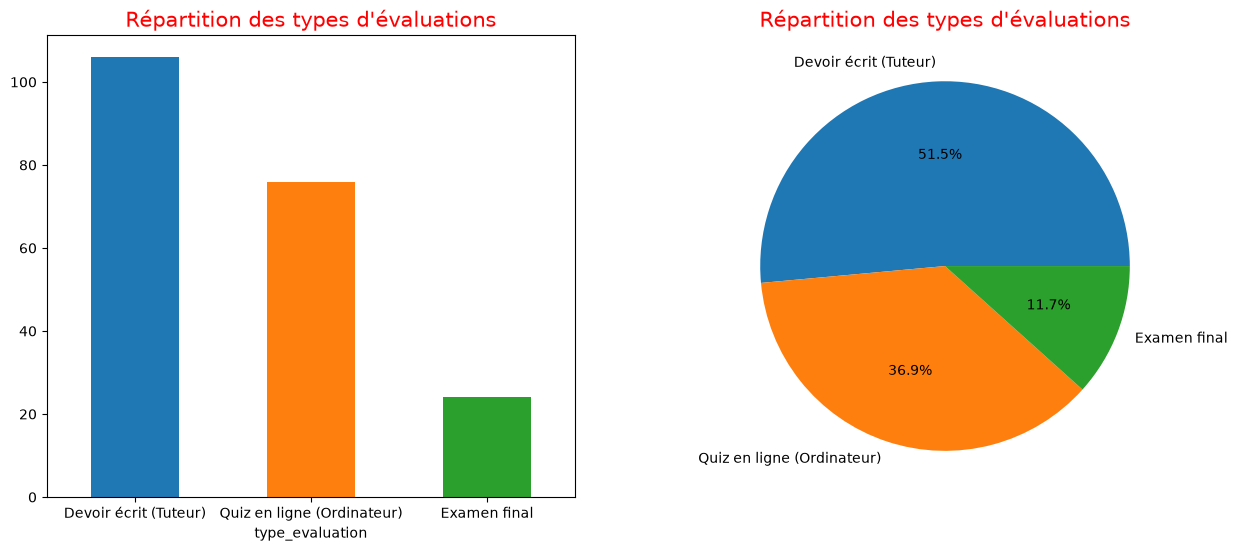

In [200]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
evaluation["type_evaluation"].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xticks(rotation=0)
plt.title("Répartition des types d'évaluations",color = 'red', size =15)

#Diagrame circulaire pour visualiser la répartition des types d'évaluations
plt.subplot(1, 2, 2)
plt.pie(evaluation["type_evaluation"].value_counts(), labels=evaluation["type_evaluation"].value_counts().index, autopct='%1.1f%%',colors=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Répartition des types d'évaluations", color = 'red', size =15)
# plt.savefig("Images/00_Repartition_types_evaluation.png", dpi = 300, bbox_inches = "tight")

<p align = "center", style = "color : blue; font-size : 30px">Interpretation du graphe : </p>

- `Un volume d'effort massif sur les devoirs écrits` : Plus de la moitié des actions d'évaluation (51,5 %) concernent des devoirs rendus à un tuteur. Cela signifie que la majeure partie de la charge de travail demandée aux étudiants et de leur production écrite se concentre sur les TMA.

- `Une régularité marquée par les quiz` : Avec 36,9 % des validations, les quiz en ligne montrent que les étudiants se connectent très fréquemment pour faire de petites évaluations automatisées en continu.

- `La rareté de l'examen final` : Les examens ne représentent que 11,7 % des lignes. C'est tout à fait logique : alors qu'un étudiant rend plusieurs devoirs et fait de nombreux quiz tout au long de l'année, il ne passe l'examen final qu'une seule fois par module.

<h3 style = "background : blue; width : 900px">
    02 - Netoyage et Analyse du dataset notes des etudiants
</h3>

In [201]:
notes_etudiants.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [202]:
notes_etudiants.shape

(173912, 5)

Le dataset notes_etudiants contient 173912 lignes et 5 colonnes. Il est important de vérifier les valeurs manquantes dans ce dataset avant de procéder à l'analyse.

In [203]:

# Renommer les colonnes en français
notes_etudiants.rename(columns={
    'id_assessment': 'id_evaluation',
    'id_student': 'id_etudiant',
    'date_submitted': 'jours_avant_remise',
    'is_banked': 'note_transferee',
    'score': 'note'
}, inplace=True)

In [204]:
notes_etudiants.head()

,id_evaluation,id_etudiant,jours_avant_remise,note_transferee,note
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [205]:
#Veridication des valeurs manquantes dans le dataset notes_etudiants
notes_etudiants.info()

<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id_evaluation       173912 non-null  int64  
 1   id_etudiant         173912 non-null  int64  
 2   jours_avant_remise  173912 non-null  int64  
 3   note_transferee     173912 non-null  int64  
 4   note                173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB


In [206]:
note_mank = notes_etudiants.isnull().mean()*100
note_mank.sort_values(ascending=False).round(3)

note                  0.099
id_evaluation         0.000
id_etudiant           0.000
jours_avant_remise    0.000
note_transferee       0.000
dtype: float64

il y'a envirion `0,099%` de valeur manquante dans la variable note ,
- Dans le domaine de l'éducation en ligne, si un étudiant a une note manquante pour un devoir obligatoire, cela signifie très souvent qu'il a rendu copie blanche, qu'il a raté la date limite, ou qu'il a déjà abandonné le cours à ce moment-là. Lui attribuer la note de 0 reflète donc parfaitement sa situation académique réelle à cet instant.

bien comme dans tout projet de datascience nos donnes manquantes sont trop petit alors je vais remplacer ces notes manquantes  par 0.

In [207]:
notes_etudiants["note"] = notes_etudiants["note"].fillna(0)  # Remplacer les valeurs manquantes par 0

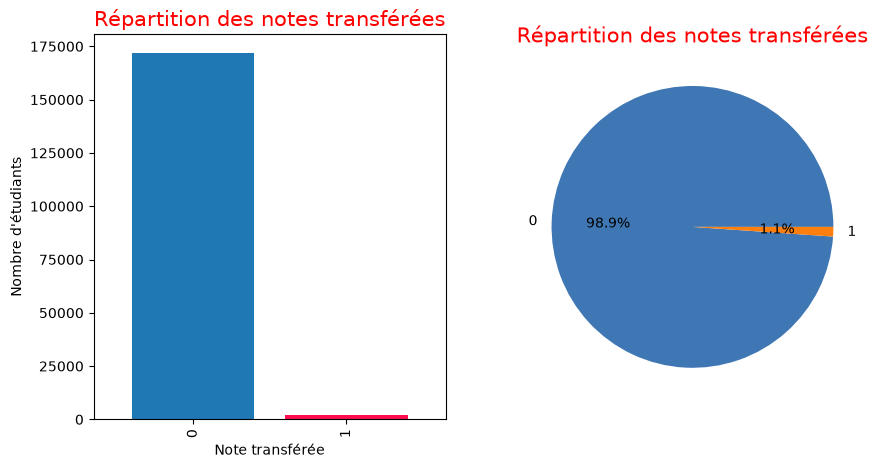

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
notes_etudiants["note_transferee"].value_counts().plot(kind='bar', width=0.8, color=['#1f77b4', "#ff0e4e"])
plt.title("Répartition des notes transférées", color = 'red', size =15)
plt.xlabel("Note transférée")
plt.ylabel("Nombre d'étudiants")

plt.subplot(1,2,2)
plt.pie(notes_etudiants["note_transferee"].value_counts(), labels=notes_etudiants["note_transferee"].value_counts().index, autopct='%1.1f%%',colors=['#3f77b4', '#ff7f0e'])
plt.title("Répartition des notes transférées", color = 'red', size =15)
#plt.savefig("Images/01_Repartition_notes_transferee.png", dpi = 300, bbox_inches = "tight")

 **Analyse métier :** \
Le graphique montre que **98,9 %** des évaluations concernent le parcours classique (les étudiants composent normalement ce semestre). 
À l'inverse, **1,1 %** des lignes représentent des notes transférées. Cela indique qu'une petite minorité d'étudiants a déjà validé ces compétences lors d'une session précédente et conserve son avantage pour alléger sa charge de travail actuelle.


## Petit visulisation 

In [209]:
notes_etudiants.columns

Index(['id_evaluation', 'id_etudiant', 'jours_avant_remise', 'note_transferee',
       'note'],
      dtype='str')

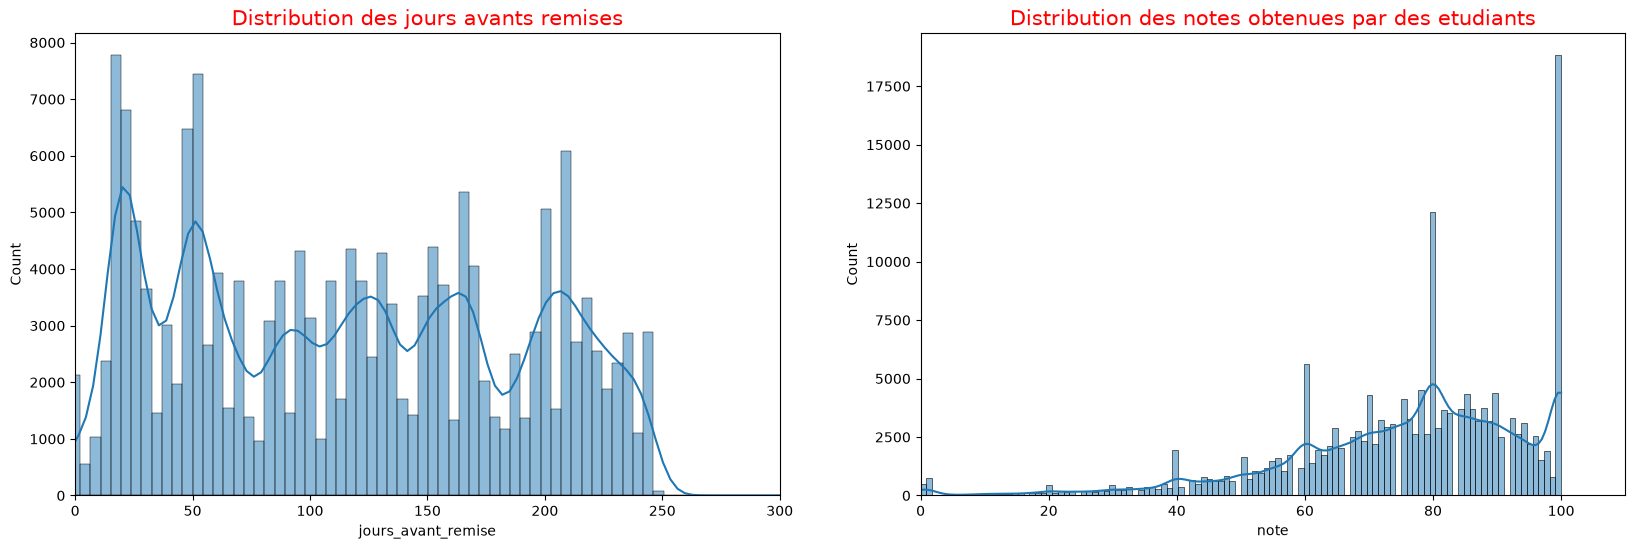

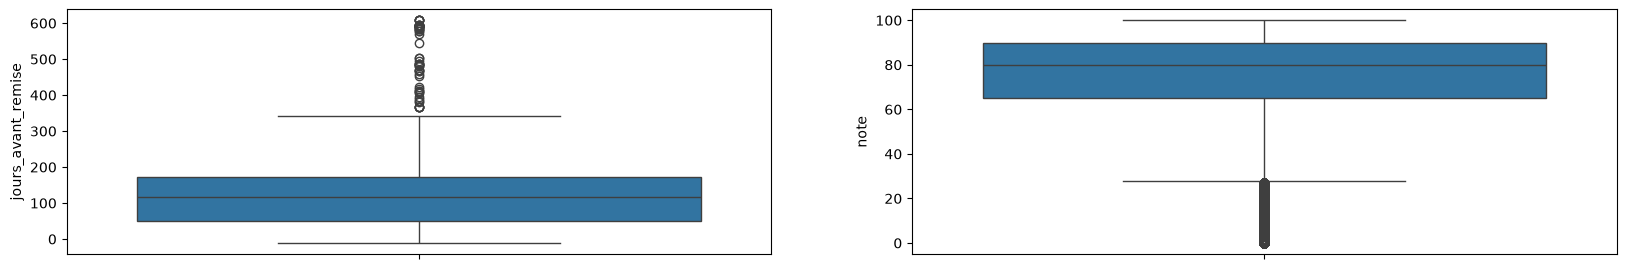

In [ ]:
plt.figure(figsize = (20,6))

#Jours avants remise 
plt.subplot(1,2,1)
plt.title("Distribution des jours avants remises", size= 15, c = "red")
sns.histplot(data = notes_etudiants, x = "jours_avant_remise", kde = True)
plt.xlim(0, 300)

#notes
plt.subplot(1,2,2)
plt.title("Distribution des notes obtenues par des etudiants", size= 15, c = "red")
sns.histplot(data = notes_etudiants, x = "note", kde = True)
plt.xlim(0, 110)


#BOXPLOT DES GRAPHES
plt.figure(figsize = (20,7))

# jours avants remises 
plt.subplot(2, 2, 3)
sns.boxplot(data =notes_etudiants, y = "jours_avant_remise")

#notes
plt.subplot(2, 2, 4)
sns.boxplot(data =notes_etudiants, y = "note")

#plt.savefig("Images/02_Distribution_(jours_avants_remises_&_notes_obtenues).png", dpi= 300, bbox_inches = "tight")

Le graphique des jours avant remise montre une distribution multi-modale étalée jusqu'à 250 jours, avec une médiane de soumission autour de 100 jours. On note la présence de quelques valeurs aberrantes extrêmes s'étendant jusqu'à 600 jours. Concernant les résultats, la distribution des notes est fortement orientée vers le haut, avec 50 % des étudiants obtenant une note située entre 65 et 90, et un pic notable à 100. Les notes inférieures à environ 28 jours constituent 

- Les étudiants rendent leurs devoirs de manière étalée sur toute l'année, généralement entre 2 et 6 mois, même si quelques rares retardataires dépassent les 600 jours. Du côté des résultats, les notes sont globalement excellentes : la plupart des étudiants se situent entre 65 et 90 sur 100, avec beaucoup de notes parfaites à 100. Les échecs ou très mauvaises notes (sous la barre des 30) restent très rares.

<h3 style = "background : blue; width : 800px">
    3 - Netoyage et Analyse du dataset profil_etudiant
</h3>

In [211]:
profil_etudiants.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [212]:
profil_etudiants.shape

(32593, 12)

In [213]:
profil_etudiants.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result'],
      dtype='str')

In [214]:
#Renommer les colonnes en français
profil_etudiants = profil_etudiants.rename(columns={
    'code_module': 'code_matiere',
    'code_presentation': 'session_cours',
    'id_student': 'id_etudiant',
    'gender': 'genre',
    'region': 'region',
    'highest_education': 'niveau_etudes_maximum',
    'imd_band': 'indice_defavorisation',
    'age_band': 'tranche_age',
    'num_of_prev_attempts': 'nombre_tentatives_precedentes',
    'studied_credits': 'credits_etudies',
    'disability': 'handicap',
    'final_result': 'resultat_final'
})

profil_etudiants.columns


Index(['code_matiere', 'session_cours', 'id_etudiant', 'genre', 'region',
       'niveau_etudes_maximum', 'indice_defavorisation', 'tranche_age',
       'nombre_tentatives_precedentes', 'credits_etudies', 'handicap',
       'resultat_final'],
      dtype='str')

In [215]:
profil_etudiants.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   code_matiere                   32593 non-null  str  
 1   session_cours                  32593 non-null  str  
 2   id_etudiant                    32593 non-null  int64
 3   genre                          32593 non-null  str  
 4   region                         32593 non-null  str  
 5   niveau_etudes_maximum          32593 non-null  str  
 6   indice_defavorisation          31482 non-null  str  
 7   tranche_age                    32593 non-null  str  
 8   nombre_tentatives_precedentes  32593 non-null  int64
 9   credits_etudies                32593 non-null  int64
 10  handicap                       32593 non-null  str  
 11  resultat_final                 32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 4.8 MB


In [216]:
prof_mank = profil_etudiants.isnull().mean()*100
prof_mank.sort_values(ascending = False).round(2)

indice_defavorisation            3.41
code_matiere                     0.00
id_etudiant                      0.00
session_cours                    0.00
genre                            0.00
region                           0.00
niveau_etudes_maximum            0.00
tranche_age                      0.00
nombre_tentatives_precedentes    0.00
credits_etudies                  0.00
handicap                         0.00
resultat_final                   0.00
dtype: float64

In [217]:
#Il y'a des valeurs manquantes dans la  "indice_defavorisation". Il est important de traiter ces valeurs manquantes avant d'effectuer toute analyse.

In [218]:
profil_etudiants["indice_defavorisation"].value_counts()

indice_defavorisation
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Name: count, dtype: int64

In [ ]:
# Correction de l'erreur de saisie : Ajout du symbole '%' manquant pour la tranche 10-20
profil_etudiants["indice_defavorisation"] = profil_etudiants["indice_defavorisation"].replace({"10-20": "10-20%"})
profil_etudiants["indice_defavorisation"].value_counts() #SLa corrrection a été effectuée avec succès, la valeur "10-20" a été remplacée par "10-20%".

indice_defavorisation
20-30%     3654
30-40%     3539
10-20%     3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Name: count, dtype: int64

<Axes: title={'center': "Repartition de l'indice de défavorisation des étudiants"}, xlabel='indice_defavorisation', ylabel='count'>

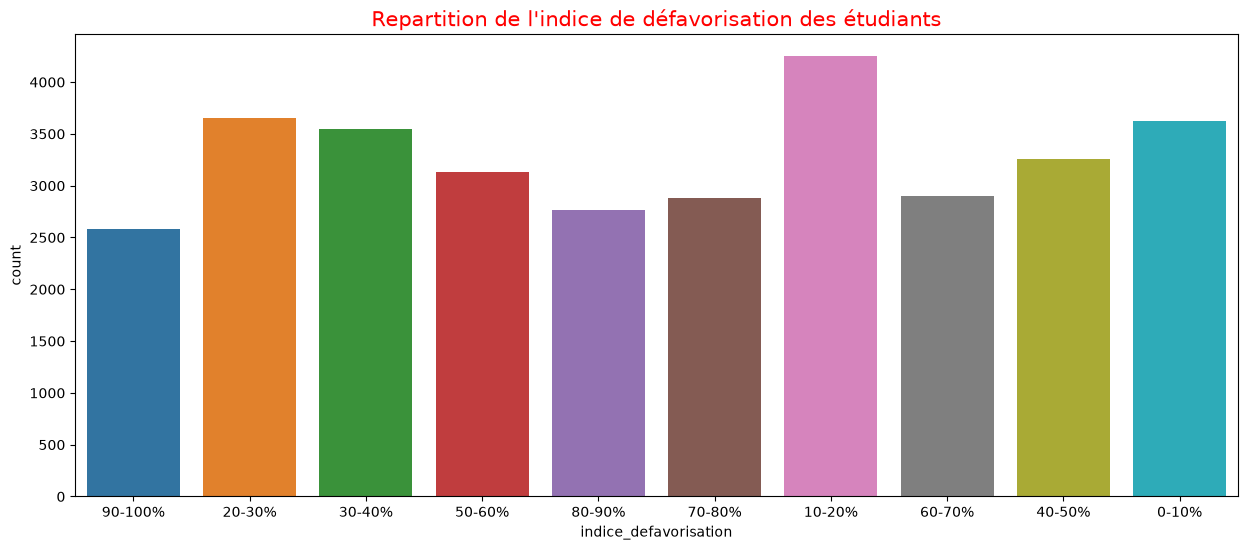

In [269]:
plt.figure(figsize=(15,6))
plt.title("Repartition de l'indice de défavorisation des étudiants", size= 15, c = "red")
sns.countplot(data = profil_etudiants, x = "indice_defavorisation", hue = "indice_defavorisation")
# plt.savefig("Images/03_Distribution_indice_defavorisation.png", dpi =300, bbox_inches = "tight")

Le graphique montre que l'université accueille un public très diversifié, issu de toutes les tranches sociales. Cependant, on remarque une présence plus forte d'étudiants venant de milieux plutôt populaires (notamment les tranches de 10% à 40% de l'indice de défavorisation). À l'inverse, les étudiants originaires des quartiers les plus riches (tranche 90-100%) sont les moins nombreux, même s'ils représentent tout de même plus de 2500 inscriptions."


In [221]:
#  je choisie de Remplacer les 3,41% de cases vides par la valeur de pauvreté 
# la plus fréquente (le mode) de la région où vit l'étudiant.
profil_etudiants['indice_defavorisation'] = profil_etudiants.groupby('region')['indice_defavorisation'].transform(lambda x: x.fillna(x.mode()[0]))


In [222]:
mank = profil_etudiants.isnull().mean()*100
mank.sort_values(ascending = False).round(2) #Toutes les valeurs manquantes ont été traitées avec succès.

code_matiere                     0.0
session_cours                    0.0
id_etudiant                      0.0
genre                            0.0
region                           0.0
niveau_etudes_maximum            0.0
indice_defavorisation            0.0
tranche_age                      0.0
nombre_tentatives_precedentes    0.0
credits_etudies                  0.0
handicap                         0.0
resultat_final                   0.0
dtype: float64

In [223]:
profil_etudiants.head()

,code_matiere,session_cours,id_etudiant,genre,region,niveau_etudes_maximum,indice_defavorisation,tranche_age,nombre_tentatives_precedentes,credits_etudies,handicap,resultat_final
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [224]:
profil_etudiants["niveau_etudes_maximum"].value_counts().head(10)

niveau_etudes_maximum
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64

In [225]:
profil_etudiants["niveau_etudes_maximum"].unique().tolist()

['HE Qualification',
 'A Level or Equivalent',
 'Lower Than A Level',
 'Post Graduate Qualification',
 'No Formal quals']

In [226]:
# Traduction en français des différents niveaux d'études
profil_etudiants["niveau_etudes_maximum"] = profil_etudiants["niveau_etudes_maximum"].replace({
    'HE Qualification': 'Enseignement supérieur (Bac+2)',
    'Lower Than A Level': 'Inférieur au Bac',
    'A Level or Equivalent': 'Niveau Bac',
    'Post Graduate Qualification': 'Master / Doctorat',
    'No Formal quals': 'Aucun diplôme officiel'
})
profil_etudiants["niveau_etudes_maximum"].value_counts()


niveau_etudes_maximum
Niveau Bac                        14045
Inférieur au Bac                  13158
Enseignement supérieur (Bac+2)     4730
Aucun diplôme officiel              347
Master / Doctorat                   313
Name: count, dtype: int64

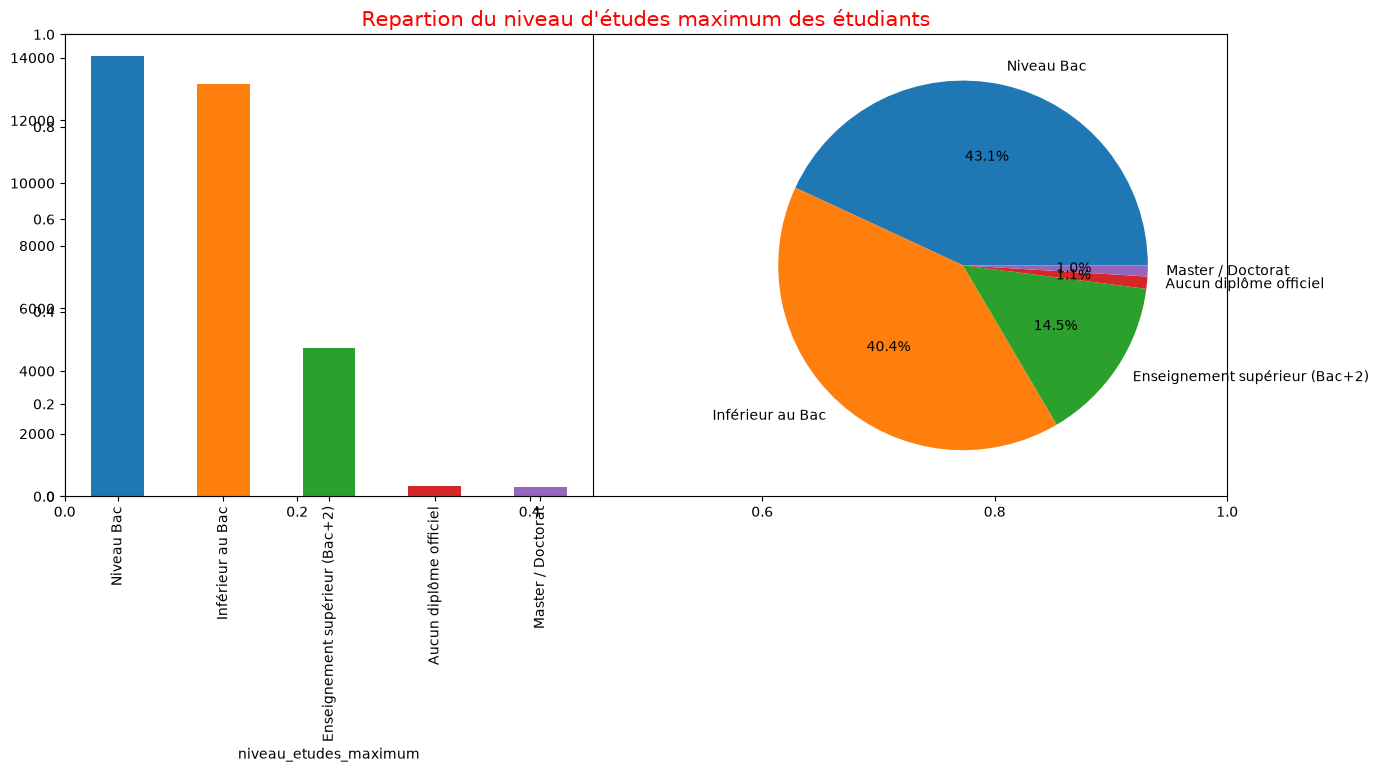

In [272]:
plt.figure(figsize = (15,6))
plt.title("Repartion du niveau d'études maximum des étudiants", size= 15, c = "red")
plt.subplot(1, 2, 1)
profil_etudiants["niveau_etudes_maximum"].value_counts().plot(kind ="bar", color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

plt.subplot(1, 2, 2)
plt.pie(profil_etudiants["niveau_etudes_maximum"].value_counts(), labels=profil_etudiants["niveau_etudes_maximum"].value_counts().index, autopct='%1.1f%%',colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])

plt.savefig("Images/04_Repartition_niveau_etudes_max.png",dpi = 300, bbox_inches = "tight")

Les graphiques montrent que l'établissement est principalement composé d'étudiants ayant un profil 'Niveau Bac' (43,1 %) ou 'Inférieur au Bac' (40,4 %), ce qui représente plus de 80 % de l'effectif global. Les profils possédant déjà un niveau d'enseignement supérieur (Bac+2) comptent pour 14,5 %. Enfin, conformément aux observations, les étudiants n'ayant 'Aucun diplôme officiel' (1,1 %) ainsi que ceux possédant un 'Master / Doctorat' (1,0 %) sont extrêmement minoritaires dans le groupe.

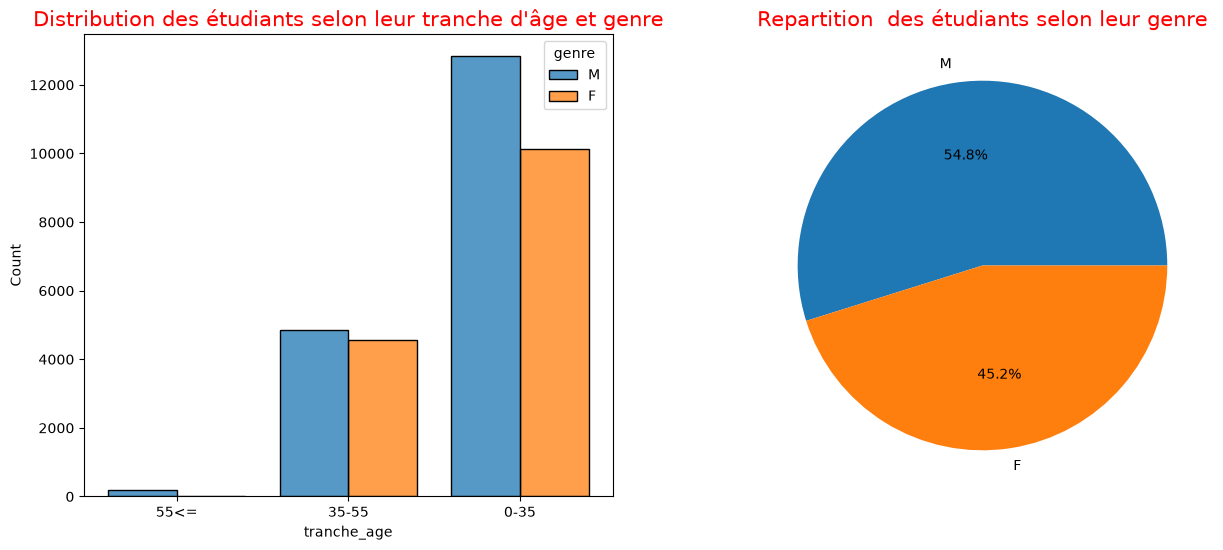

In [ ]:
#Analyse de la representation des étudiants selon leur tranche d'âge et genre
plt.figure(figsize = (15,6))        
plt.subplot(1, 2, 1)
plt.title("Distribution des étudiants selon leur tranche d'âge et genre", size= 15, c = "red")
sns.histplot(data = profil_etudiants, x = "tranche_age", hue = "genre", multiple = "dodge", shrink = 0.8, palette = ['#1f77b4', '#ff7f0e'])

plt.subplot(1, 2, 2)
plt.title("Repartition  des étudiants selon leur genre", size= 15, c = "red")
plt.pie(profil_etudiants["genre"].value_counts(), labels=profil_etudiants["genre"].value_counts().index, autopct='%1.1f%%', colors=['#1f77b4', '#ff7f0e'])

# plt.savefig("Images/05_Repartition_genre_selon_tranche_age.png", bbox_inches="tight", dpi =300)

L'analyse démographique montre que la population étudiante est globalement masculine, avec 54,8 % d'hommes contre 45,2 % de femmes. De plus, le groupe est majoritairement très jeune : la tranche des 0-35 ans est de loin la plus représentée. On remarque également que si les hommes sont plus nombreux chez les moins de 35 ans, la répartition entre hommes et femmes devient presque parfaitement égale dans la tranche des 35-55 ans. Les étudiants de plus de 55 ans restent quant à eux très marginaux(Rien que des Hommes)

In [229]:
profil_etudiants.head()

,code_matiere,session_cours,id_etudiant,genre,region,niveau_etudes_maximum,indice_defavorisation,tranche_age,nombre_tentatives_precedentes,credits_etudies,handicap,resultat_final
0,AAA,2013J,11391,M,East Anglian Region,Enseignement supérieur (Bac+2),90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,Enseignement supérieur (Bac+2),20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,Niveau Bac,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,Niveau Bac,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Inférieur au Bac,50-60%,0-35,0,60,N,Pass


In [230]:
# Nombre de tentative precedentes
profil_etudiants["nombre_tentatives_precedentes"].value_counts().head(20)

nombre_tentatives_precedentes
0    28421
1     3299
2      675
3      142
4       39
5       13
6        4
Name: count, dtype: int64

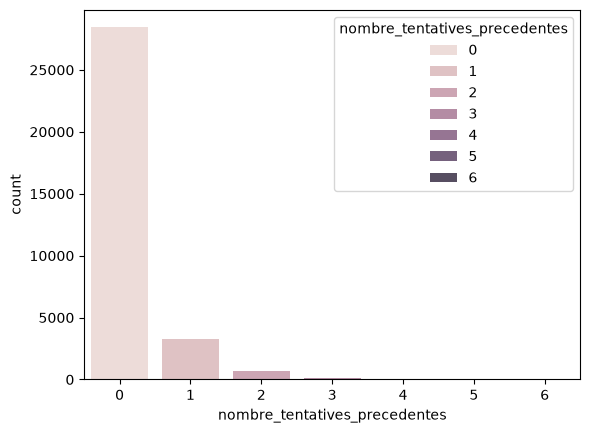

In [ ]:
#Representaton graphique
sns.countplot(data =profil_etudiants, x = "nombre_tentatives_precedentes", hue = "nombre_tentatives_precedentes", alpha = 0.8)

#plt.savefig("Images/06_Repartition_nombre_tentatives_precedentes.png", dpi =300, bbox_inches = "tight")

Analyse sur l'etat des etudiant Handicap

In [232]:
profil_etudiants["handicap"].value_counts()

handicap
N    29429
Y     3164
Name: count, dtype: int64

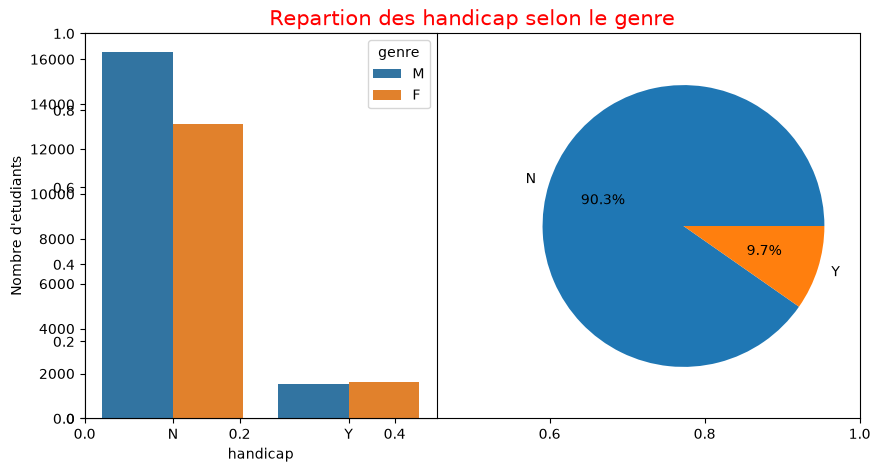

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10,5))

plt.title("Repartion des handicap selon le genre",size = 15, c = "red")
plt.subplot(1,2,1)
sns.countplot(data  = profil_etudiants ,  x = "handicap", hue = "genre")

plt.ylabel("Nombre d'etudiants")

plt.subplot(1,2,2)
plt.pie(profil_etudiants["handicap"].value_counts(), labels = profil_etudiants["handicap"].value_counts().index, autopct= "%1.1f%%")
plt.show()
# plt.savefig("Images/07_Repartition_handicap_selon_genre.png", dpi = 300, bbox_inches = "tight")

Il y'a environ 9,7% des etudiant qui sont en situation d'handicaps, de plus cil y'a plus de femme en situaation d'handicaps que les hommes

`Visualisation des resultat des etudiants `

In [234]:
profil_etudiants["resultat_final"].value_counts()

resultat_final
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [235]:
#Traduction en français des différents résultats finaux
profil_etudiants["resultat_final"] = profil_etudiants["resultat_final"].replace({
    'Pass': 'Réussite',
    'Withdrawn': 'Abandon',
    'Fail': 'Échec',
    'Distinction': 'Mention / Distinction'
})


Ces nom sont les différents résultats finaux des étudiants. Il est important de noter que ces résultats sont basés sur les performances académiques des étudiants et peuvent varier en fonction de divers facteurs tels que le niveau d'études, le genre, la tranche d'âge, etc.

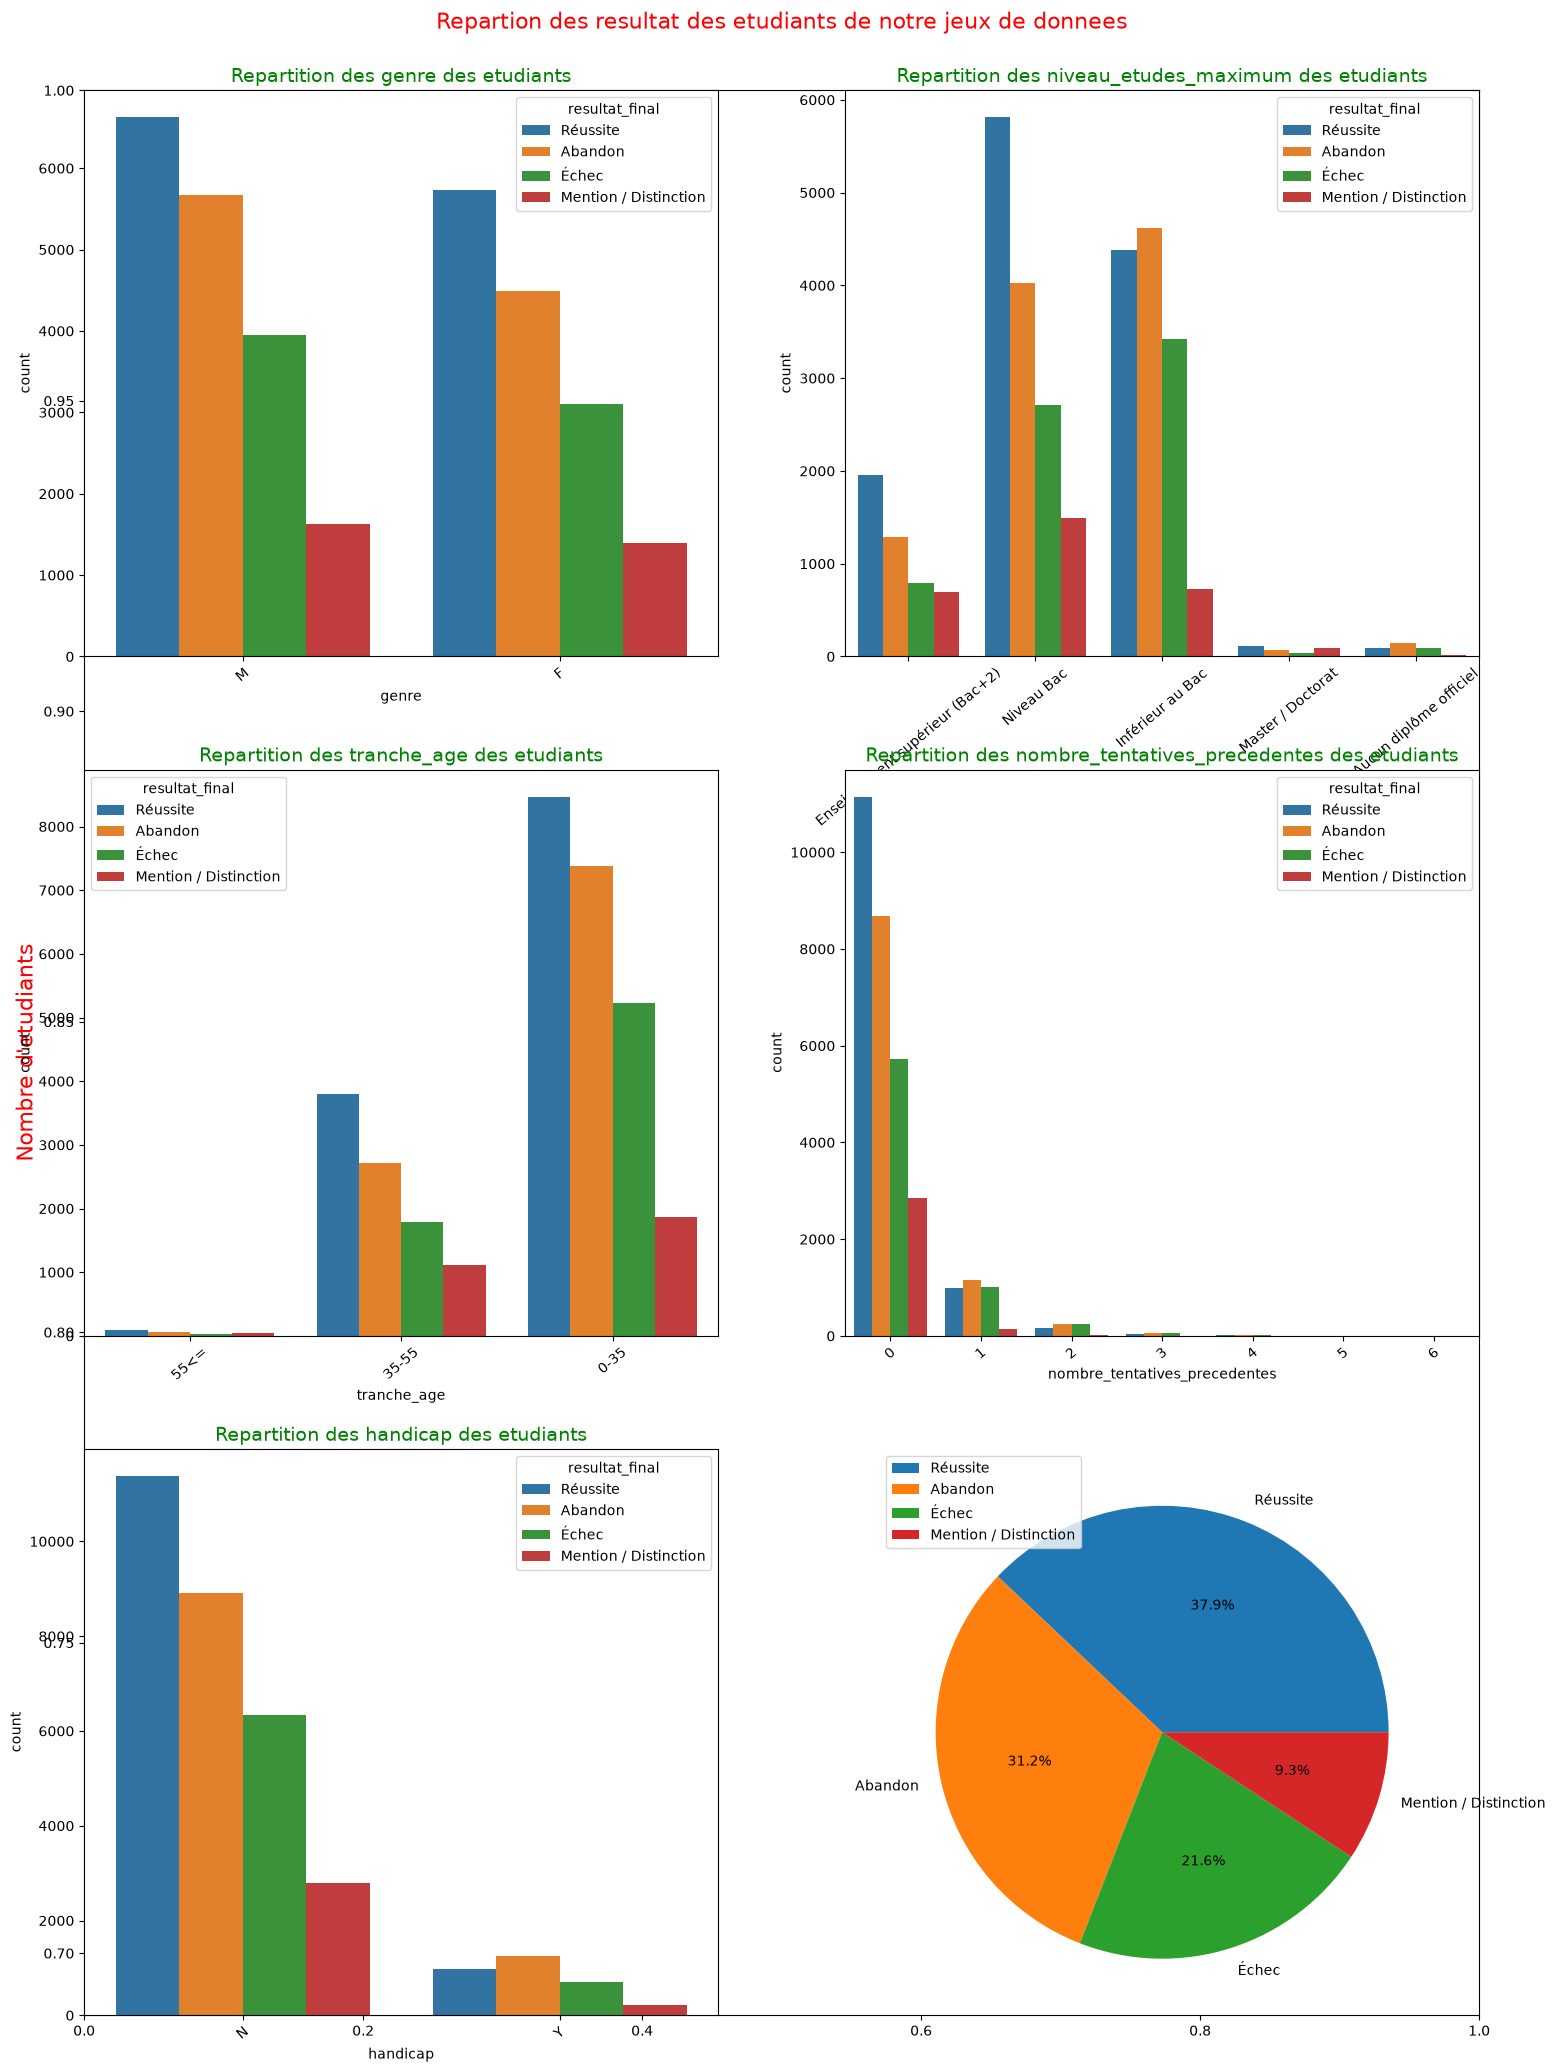

In [ ]:

#Diagramme de bar
plt.figure(figsize=(18,25))
plt.title("Repartion des resultat des etudiants de notre jeux de donnees\n\n", size = 16, c = "red")
plt.ylabel("Nombre d'etudiants", c = "red", size = 16)
plt.ylim(0.69, 1.0)

colonne = colonne = profil_etudiants.drop(columns=["indice_defavorisation", "region", "credits_etudies", "resultat_final"])
colonne  = colonne.iloc[:, 3:].columns.tolist()

for i in range(len(colonne)):
    plt.subplot(3,2,i+1)
    plt.title(f"Repartition des {colonne[i]} des etudiants", c = "green", size = 14)
    sns.countplot(data = profil_etudiants, x = colonne[i], hue = "resultat_final")
    plt.xticks(rotation = 40)

#Diag circulaire pour les resultat
plt.subplot(3,2,6)
plt.pie(profil_etudiants["resultat_final"].value_counts(), labels =profil_etudiants["resultat_final"].value_counts().index, autopct= "%1.1f%%" )
plt.legend()

#plt.savefig("Images/08_Repartition_des_resultats_etudiants.png", dpi = 300, bbox_inches = "tight")

`L'analyse croisée met en lumière que le décrochage scolaire (l'abandon) n'est pas réparti au hasard. Si le genre et l'âge jouent un rôle mineur, le passé scolaire et les barrières physiques ou de santé sont déterminants. Les étudiants ayant un niveau inférieur au Bac, ceux en situation de redoublement, ou ceux ayant déclaré un handicap présentent un risque de décrochage critique, l'abandon devenant chez eux le premier résultat statistique. Ce sont précisément ces trois leviers que notre futur modèle de Machine Learning devra utiliser pour repérer et aider les profils fragiles dès le début de l'année.`

<h3 style = "background : blue ; padding :10px 0 10px 0; color :white">Netoyage et analyse du dataset inscription</h3>

In [237]:
inscription.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [238]:
inscription.shape

(32593, 5)

In [239]:
inscription.columns

Index(['code_module', 'code_presentation', 'id_student', 'date_registration',
       'date_unregistration'],
      dtype='str')

In [240]:
inscription.rename(columns={
    'code_module': 'code_matiere',
    'code_presentation': 'session_cours',
    'id_student': 'id_etudiant',
    'date_registration': 'date_inscription',
    'date_unregistration': 'date_desinscription'
}, inplace=True)

inscription.columns

Index(['code_matiere', 'session_cours', 'id_etudiant', 'date_inscription',
       'date_desinscription'],
      dtype='str')

In [241]:
inscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_matiere         32593 non-null  str    
 1   session_cours        32593 non-null  str    
 2   id_etudiant          32593 non-null  int64  
 3   date_inscription     32548 non-null  float64
 4   date_desinscription  10072 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.5 MB


In [242]:
inscription.isnull().mean()*100

code_matiere            0.000000
session_cours           0.000000
id_etudiant             0.000000
date_inscription        0.138066
date_desinscription    69.097659
dtype: float64

In [243]:
inscription["date_inscription"] = inscription["date_inscription"].fillna(inscription["date_inscription"].median())  # Remplacer les valeurs manquantes par la median date d'inscription

inscription["date_desinscription"] = inscription["date_desinscription"].fillna(0)  # Remplacer les valeurs manquantes par le chiffre 0

inscription.isnull().sum()  # Vérification des valeurs manquantes après le traitement

code_matiere           0
session_cours          0
id_etudiant            0
date_inscription       0
date_desinscription    0
dtype: int64


1. La variable 'date_inscription' (date_registration) :
   - Signification des valeurs négatives (-) : Les dates sont exprimées en nombre de 
     jours par rapport au début officiel des cours (qui représente le jour 0). 
     Une valeur négative (par exemple -30) indique que l'étudiant s'est inscrit 
     à l'avance, exactement 30 jours avant le lancement du module. Plus le chiffre 
     est bas, plus l'étudiant a anticipé sa rentrée.
   - Traitement des valeurs manquantes (0,13 %) : En raison de leur volume infime 
     (environ 42 étudiants), elles sont remplacées par la valeur médiane globale 
     afin de conserver l'intégrité du jeu de données sans perturber la distribution.

2. La variable 'date_desinscription' (date_unregistration) :
   - Signification des valeurs manquantes (NaN / 60 %) : Ces données manquantes ne 
     sont pas des erreurs. Elles ont une signification métier cruciale : elles 
     représentent les étudiants qui sont restés inscrits et ont suivi la formation 
     jusqu'au bout. À l'inverse, une valeur chiffrée n'apparaît que si l'étudiant 
     a officiellement abandonné le cours (indiquant le jour précis de son départ).
   - Traitement : Pour la suite du projet, ces valeurs manquantes seront remplacées 
     par 0 (ou transformées en un indicateur binaire) afin de signaler au modèle 
     de Machine Learning que ces étudiants n'ont pas abandonné.

- Visualisation du dataset inscription 

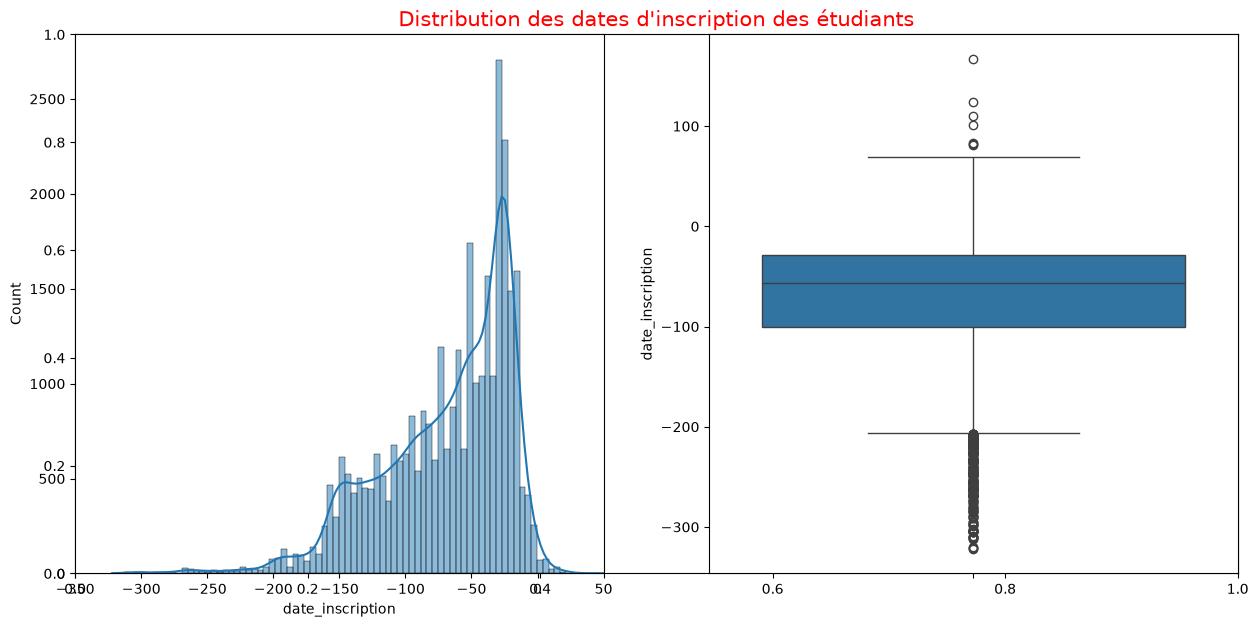

In [ ]:
plt.figure(figsize = (15,7))
plt.title("Distribution des dates d'inscription des étudiants", size= 15, c = "red")
plt.subplot(1,2,1)
sns.histplot(data = inscription,x = "date_inscription", kde = True)
plt.xlim(-350, 50)
plt.subplot(1,2,2)
sns.boxplot(data = inscription, y = "date_inscription")

# plt.savefig("Images/09_Distribution_date_inscription.png", dpi = 300, bbox_inches = "tight")

Le graphique de la variable date_inscription montre que la population étudiante anticipe majoritairement son entrée en formation. La moitié centrale des inscriptions s'effectue entre 1 et 3 mois avant le début des cours, avec un pic d'inscriptions massif situé à -30 jours. On note la présence de valeurs aberrantes aux deux extrêmes : des profils ultra-anticipés s'inscrivant jusqu'à 300 jours à l'avance, et une minorité d'inscriptions tardives survenant après le lancement officiel des cours (allant jusqu'à +170 jours).

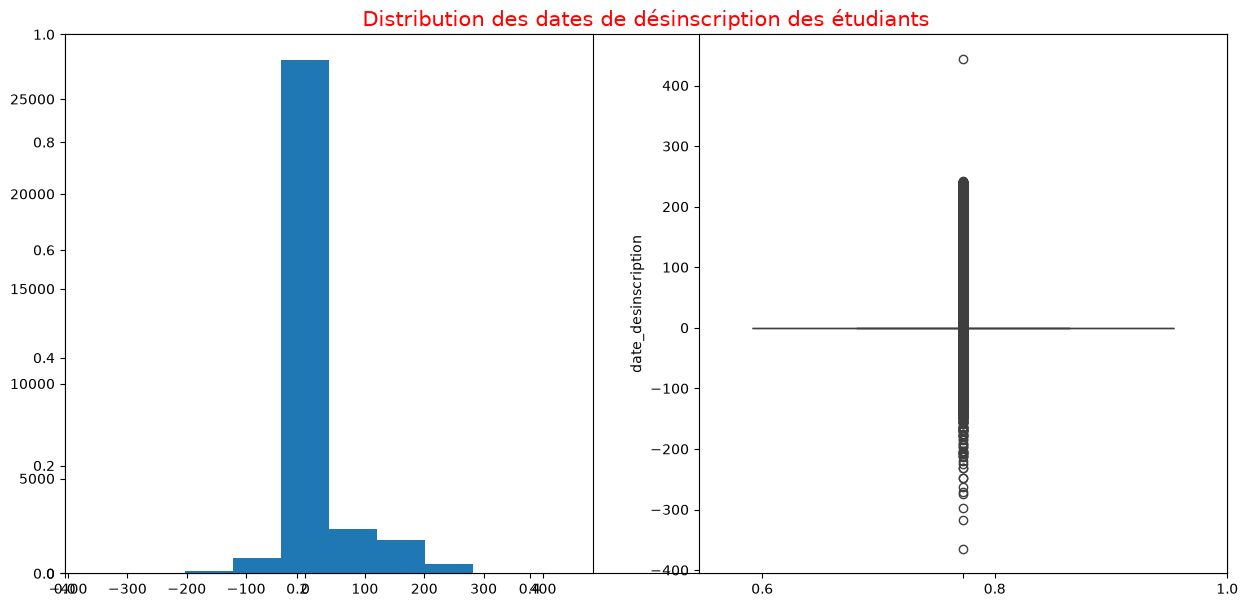

In [ ]:
#Desinscription des etudiants
plt.figure(figsize = (15,7))
plt.title("Distribution des dates de désinscription des étudiants", size= 15, c = "red")
plt.subplot(1,2,1)
plt.hist(inscription["date_desinscription"])
plt.subplot(1,2,2)
sns.boxplot(data = inscription   , y = "date_desinscription")

# plt.savefig("Images/010_Distribution_date_desinscription.png", dpi = 300, bbox_inches = "tight")

Le graphique de la variable date_desinscription met en évidence le succès du traitement des données manquantes, illustré par un pic massif à 0 représentant les 60 % d'étudiants ayant suivi le cours jusqu'au bout. Pour les étudiants ayant abandonné, la distribution montre que le décrochage survient principalement au cours des 250 premiers jours de la formation. Quelques désinscriptions très minoritaires ont également lieu en amont du lancement officiel du cours.

<h3 style = "background : blue ; padding :10px 0 10px 0; color :white">Netoyage et analyse du dataset clic_platforme_etudiant </h3>

In [246]:
interactions_plateforme.head()

,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [247]:
interactions_plateforme.shape # Plus de 10 million echantillons

(10655280, 6)

In [248]:
interactions_plateforme.columns

Index(['code_module', 'code_presentation', 'id_student', 'id_site', 'date',
       'sum_click'],
      dtype='str')

In [249]:
interactions_plateforme = interactions_plateforme.rename(columns={
    'code_module': 'code_matiere',
    'code_presentation': 'session_cours',
    'id_student': 'id_etudiant',
    'id_site': 'id_ressource',
    'date': 'jour_clic',
    'sum_click': 'nombre_clics'
})

interactions_plateforme.head()

# Note métier : Le jour 0 représente le début officiel des cours.
# Les valeurs négatives (-) indiquent des actions réalisées EN AVANCE 
# (ex: inscription ou clics sur la plateforme 30 jours avant la rentrée).


,code_matiere,session_cours,id_etudiant,id_ressource,jour_clic,nombre_clics
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [250]:
interactions_plateforme.info()

<class 'pandas.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column         Dtype
---  ------         -----
 0   code_matiere   str  
 1   session_cours  str  
 2   id_etudiant    int64
 3   id_ressource   int64
 4   jour_clic      int64
 5   nombre_clics   int64
dtypes: int64(4), str(2)
memory usage: 569.1 MB


In [251]:
interactions_plateforme.isnull().mean()*100  # Vérification des valeurs manquantes dans le dataset interactions_plateforme, ha aucune valeur manquante n'a été trouvée.

code_matiere     0.0
session_cours    0.0
id_etudiant      0.0
id_ressource     0.0
jour_clic        0.0
nombre_clics     0.0
dtype: float64

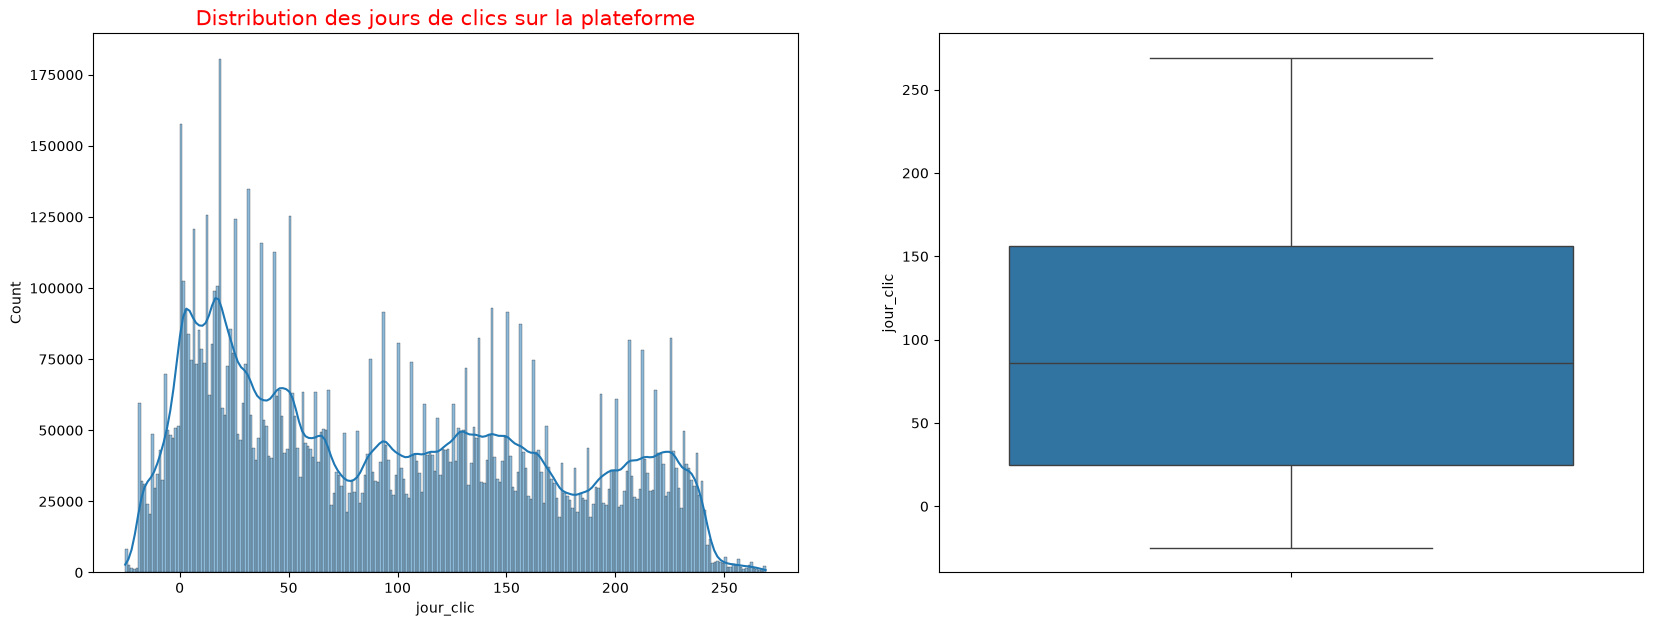

In [280]:
plt.figure(figsize = (20,7))
plt.subplot(1,2,1)
plt.title("Distribution des jours de clics sur la plateforme", size= 15, c = "red")
sns.histplot(data = interactions_plateforme, x = "jour_clic", kde = True)

plt.subplot(1,2,2)
sns.boxplot(data = interactions_plateforme, y = "jour_clic")
plt.savefig("Images/011_Distribution_jours_clics_plateformes.png", dpi = 300, bbox_inches = "tight")

Le graphique de la distribution des clics montre une activité qui démarre dès trois semaines avant le début officiel des cours (jours négatifs), traduisant la curiosité des étudiants. L'activité atteint son maximum absolu durant les 50 premiers jours du semestre. Par la suite, le trafic adopte un profil en dents de scie avec des regains d'activité cycliques (autour des jours 100, 150 et 220) qui coïncident avec les échéances des évaluations, avant de s'effondrer après le jour 240 à la fin de la session.

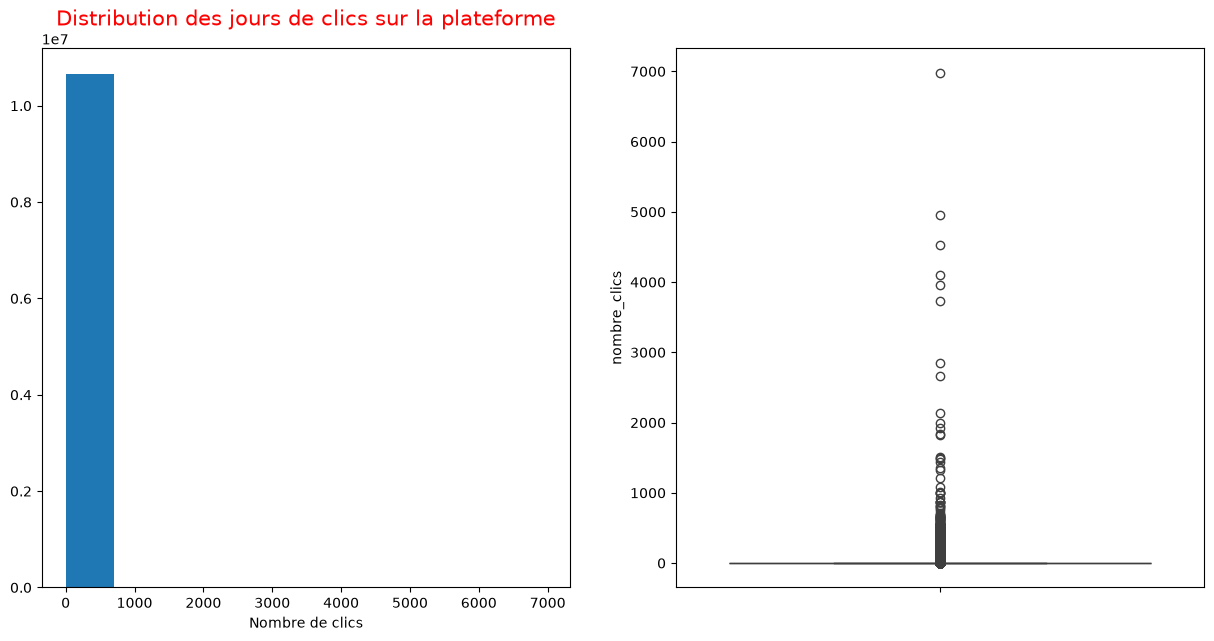

In [281]:
plt.figure(figsize = (15,7))
plt.subplot(1,2,1)
plt.title("Distribution des jours de clics sur la plateforme", size= 15, c = "red")
plt.hist(interactions_plateforme["nombre_clics"])
plt.xlabel("Nombre de clics")

plt.subplot(1,2,2)
sns.boxplot(data = interactions_plateforme, y = "nombre_clics")
plt.savefig("Images/012_Distribution_nombres_clics.png", dpi = 300, bbox_inches = "tight")

Les graphiques du nombre de clics révèlent une distribution fortement asymétrique. L'écrasante majorité des interactions quotidiennes se concentre sur un faible volume de clics (généralement inférieur à 100 clics par jour). À l'inverse, le boxplot met en lumière la présence de comportements extrêmes et atypiques, où certains étudiants accumulent plusieurs milliers de clics en une seule journée, atteignant des pics exceptionnels à près de 7 000 clics.

<h3 style = "background : blue ; padding :10px 0 10px 0; color :white">Netoyage et analyse du dataset materiel_pedagogique </h3>

In [254]:
ressources_pedago.head()

,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [255]:
ressources_pedago.shape

(6364, 6)

In [256]:
ressources_pedago.columns

Index(['id_site', 'code_module', 'code_presentation', 'activity_type',
       'week_from', 'week_to'],
      dtype='str')

In [257]:
# Traduction en français des colonnes de la table des ressources (VLE)
ressources_pedago = ressources_pedago.rename(columns={
    'id_site': 'id_ressource',
    'code_module': 'code_matiere',
    'code_presentation': 'session_cours',
    'activity_type': 'type_activite',
    'week_from': 'semaine_debut',
    'week_to': 'semaine_fin'
})
ressources_pedago.head()

,id_ressource,code_matiere,session_cours,type_activite,semaine_debut,semaine_fin
0,546943,AAA,2013J,resource,NaN,NaN
1,546712,AAA,2013J,oucontent,NaN,NaN
2,546998,AAA,2013J,resource,NaN,NaN
3,546888,AAA,2013J,url,NaN,NaN
4,547035,AAA,2013J,resource,NaN,NaN


In [258]:
#Detection des valeurs manquantes dans le dataset ressources_pedago
ressources_pedago.info()

<class 'pandas.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_ressource   6364 non-null   int64  
 1   code_matiere   6364 non-null   str    
 2   session_cours  6364 non-null   str    
 3   type_activite  6364 non-null   str    
 4   semaine_debut  1121 non-null   float64
 5   semaine_fin    1121 non-null   float64
dtypes: float64(2), int64(1), str(3)
memory usage: 393.3 KB


In [259]:
ressources_pedago.isnull().mean()*100  # Vérification des valeurs manquantes dans le dataset ressources_pedago

id_ressource      0.000000
code_matiere      0.000000
session_cours     0.000000
type_activite     0.000000
semaine_debut    82.385292
semaine_fin      82.385292
dtype: float64

Le taux de 82 % de valeurs manquantes dans les variables de planification hebdomadaire (semaine_debut et semaine_fin) nous indique que la très grande majorité des ressources pédagogiques en ligne ne possède aucune contrainte temporelle. Elles restent accessibles aux étudiants en continu, du début à la fin de la formation. Seule une minorité de ressources (18 %) est verrouillée sur des semaines spécifiques du calendrier.

In [260]:
ressources_pedago["semaine_debut"] = ressources_pedago["semaine_debut"].fillna(ressources_pedago["semaine_debut"].median())  # Remplacer les valeurs manquantes par la mediane semaine_debut    
ressources_pedago["semaine_fin"] = ressources_pedago["semaine_fin"].fillna(ressources_pedago["semaine_fin"].median())  # Remplacer les valeurs manquantes par la mediane semaine_fin

In [261]:
ressources_pedago.isnull().mean()*100    #Correction

id_ressource     0.0
code_matiere     0.0
session_cours    0.0
type_activite    0.0
semaine_debut    0.0
semaine_fin      0.0
dtype: float64

In [262]:
ressources_pedago["type_activite"].unique()

<ArrowStringArray>
[      'resource',      'oucontent',            'url',       'homepage',
        'subpage',       'glossary',        'forumng',  'oucollaborate',
       'dataplus',           'quiz',   'ouelluminate',  'sharedsubpage',
  'questionnaire',           'page',   'externalquiz',         'ouwiki',
       'dualpane', 'repeatactivity',         'folder',   'htmlactivity']
Length: 20, dtype: str

In [263]:
#Renommer les types d'activités par leurs noms en français
ressources_pedago['type_activite'] = ressources_pedago['type_activite'].replace({
    'resource': 'Document', 'oucontent': 'Contenu Interactif', 'url': 'Lien Web',
    'homepage': 'Page d\'Accueil', 'subpage': 'Sous-Page', 'glossary': 'Lexique',
    'forumng': 'Forum', 'oucollaborate': 'Classe Virtuelle', 'dataplus': 'Base de Données',
    'quiz': 'Quiz', 'ouelluminate': 'Webinaire', 'sharedsubpage': 'Sous-Page Partagée',
    'questionnaire': 'Sondage', 'page': 'Page Web', 'externalquiz': 'Quiz Externe',
    'ouwiki': 'Wiki', 'dualpane': 'Double Panneau', 'repeatactivity': 'Activité Répétée',
    'folder': 'Dossier', 'htmlactivity': 'Activité HTML'
})


In [264]:
ressources_pedago["type_activite"].unique()

<ArrowStringArray>
[          'Document', 'Contenu Interactif',           'Lien Web',
     'Page d'Accueil',          'Sous-Page',            'Lexique',
              'Forum',   'Classe Virtuelle',    'Base de Données',
               'Quiz',          'Webinaire', 'Sous-Page Partagée',
            'Sondage',           'Page Web',       'Quiz Externe',
               'Wiki',     'Double Panneau',   'Activité Répétée',
            'Dossier',      'Activité HTML']
Length: 20, dtype: str

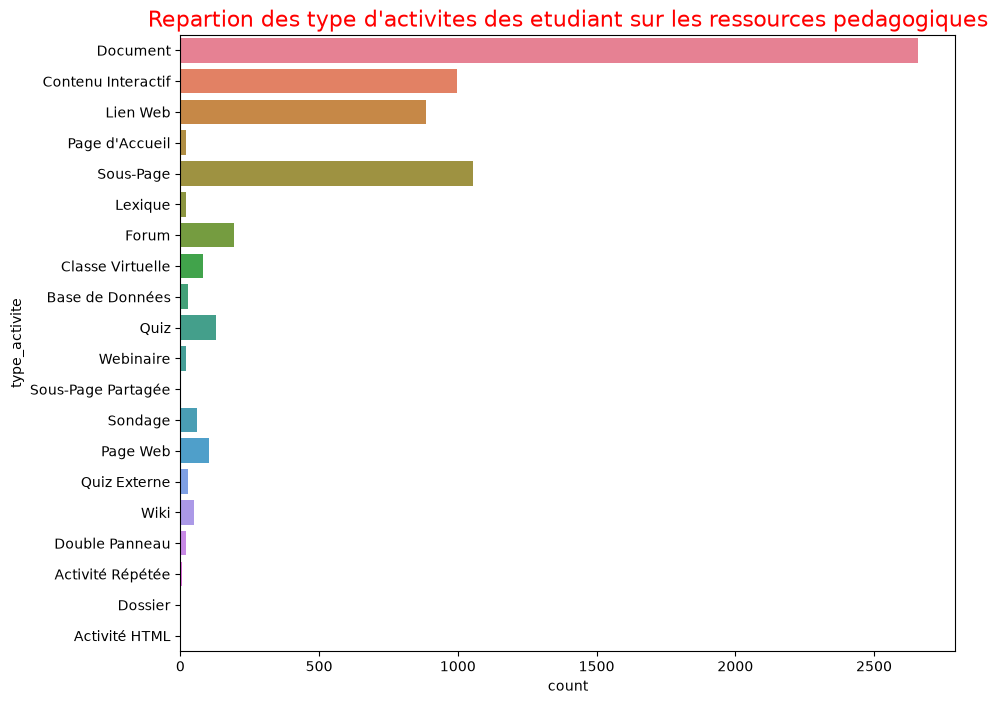

In [ ]:
plt.figure(figsize = (10, 8))
sns.countplot(data = ressources_pedago, y = "type_activite", hue = "type_activite")
plt.title("Repartion des type d'activites des etudiant sur les ressources pedagogiques", c = "red", size = 16)
# plt.savefig("Images/013_Repartition_types_avtivites_sur_ressources.png", dpi = 300, bbox_inches = "tight")
plt.show()

Le graphique de répartition des types d'activités montre que le catalogue pédagogique de l'université est massivement dominé par les 'Documents' (plus de 2 600 éléments), constituant le pilier central de la formation. Viennent ensuite les structures de navigation comme les 'Sous-Pages' et les formats de 'Contenu Interactif', qui comptent chacun environ 1 000 ressources. À l'inverse, les outils collaboratifs ou de compléments techniques comme les 'Wikis', 'Dossiers' ou 'Activités HTML' sont extrêmement marginaux, indiquant une faible exploitation de ces formats dans l'architecture des modules.